# 1: Imports and Setup

In [14]:
import torch
print(f"Version installée : {torch.__version__}")

Version installée : 2.7.1+cpu


In [15]:
# TEST CELL - Check if we can load data
import numpy as np
import pickle
import os

PROCESSED_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed"

try:
    X_test = np.load(os.path.join(PROCESSED_DIR, 'X.npy'))
    print(f"✅ X loaded successfully! Shape: {X_test.shape}")
    
    y_test = np.load(os.path.join(PROCESSED_DIR, 'y.npy'))
    print(f"✅ y loaded successfully! Shape: {y_test.shape}")
    
    with open(os.path.join(PROCESSED_DIR, 'metadata.pkl'), 'rb') as f:
        meta = pickle.load(f)
    print(f"✅ Metadata loaded! Classes: {meta['crop_names']}")
    
    print("\n✅ All data files found! Notebook 4 should work.")
    
except FileNotFoundError as e:
    print(f"❌ File not found: {e}")
    print("\nTry checking the path. Possible correct paths:")
    print("  - california_preprocessed")
    print("  - california")
    print("  - california_processed")
    
except Exception as e:
    print(f"❌ Error: {e}")

✅ X loaded successfully! Shape: (6537, 36, 13)
✅ y loaded successfully! Shape: (6537,)
✅ Metadata loaded! Classes: {36: 'Alfalfa', 57: 'Rice', 69: 'Grapes', 74: 'Pistachios', 204: 'Almonds'}

✅ All data files found! Notebook 4 should work.


In [16]:
# ============================================================================
# PART 5: MCTNet MODEL IMPLEMENTATION
# Following paper Sections 2.3 (Figures 3-6)
# ============================================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("="*70)
print("PART 5: MCTNet MODEL IMPLEMENTATION")
print("="*70)
print("\nPaper Reference:")
print("  - Section 2.3: MCTNet Architecture (Figure 3)")
print("  - Section 2.3.1: Transformer Sub-module + ALPE (Figures 4-5)")
print("  - Section 2.3.2: CNN Sub-module (Figure 6)")
print("  - Table 3: Hyperparameters")
print("="*70)

Using device: cpu
PART 5: MCTNet MODEL IMPLEMENTATION

Paper Reference:
  - Section 2.3: MCTNet Architecture (Figure 3)
  - Section 2.3.1: Transformer Sub-module + ALPE (Figures 4-5)
  - Section 2.3.2: CNN Sub-module (Figure 6)
  - Table 3: Hyperparameters


# 2: Load Preprocessed Data

In [17]:
# ============================================================================
# LOAD PREPROCESSED DATA (from Part 4)
# ============================================================================

PROCESSED_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed"

# Load data
X = np.load(os.path.join(PROCESSED_DIR, 'X.npy'))
y = np.load(os.path.join(PROCESSED_DIR, 'y.npy'))
masks = np.load(os.path.join(PROCESSED_DIR, 'masks.npy'))
train_idx = np.load(os.path.join(PROCESSED_DIR, 'train_indices.npy'))
val_idx = np.load(os.path.join(PROCESSED_DIR, 'val_indices.npy'))
test_idx = np.load(os.path.join(PROCESSED_DIR, 'test_indices.npy'))

# Load metadata
with open(os.path.join(PROCESSED_DIR, 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

print("="*70)
print("DATA LOADED")
print("="*70)
print(f"X shape: {X.shape} (samples, time_steps={X.shape[1]}, bands={X.shape[2]})")
print(f"y shape: {y.shape}")
print(f"masks shape: {masks.shape}")
print(f"Classes: {metadata['crop_names']}")
print(f"Training samples: {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")
print(f"Test samples: {len(test_idx)}")

DATA LOADED
X shape: (6537, 36, 13) (samples, time_steps=36, bands=13)
y shape: (6537,)
masks shape: (6537, 36, 10)
Classes: {36: 'Alfalfa', 57: 'Rice', 69: 'Grapes', 74: 'Pistachios', 204: 'Almonds'}
Training samples: 4578
Validation samples: 978
Test samples: 981


#  3: Dataset Class

In [18]:
# ============================================================================
# PYTORCH DATASET
# ============================================================================

class CropDataset(Dataset):
    """Dataset for crop classification with Sentinel-2 time series"""
    
    def __init__(self, X, y, masks, indices):
        """
        Parameters:
        -----------
        X : ndarray
            Features of shape (n_samples, time_steps, bands)
        y : ndarray
            Labels of shape (n_samples,)
        masks : ndarray
            ALPE masks of shape (n_samples, time_steps, bands)
        indices : ndarray
            Indices to select from the data
        """
        self.X = torch.FloatTensor(X[indices])
        self.y = torch.LongTensor(y[indices])
        self.masks = torch.FloatTensor(masks[indices])
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.masks[idx], self.y[idx]

# Create datasets
train_dataset = CropDataset(X, y, masks, train_idx)
val_dataset = CropDataset(X, y, masks, val_idx)
test_dataset = CropDataset(X, y, masks, test_idx)

print("\n" + "="*70)
print("DATASETS CREATED")
print("="*70)
print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset:   {len(val_dataset)} samples")
print(f"Test dataset:  {len(test_dataset)} samples")

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")


DATASETS CREATED
Train dataset: 4578 samples
Val dataset:   978 samples
Test dataset:  981 samples
Batch size: 32


# 4: CNN Sub-module (Figure 6)

In [19]:
class CNNSubmodule(nn.Module):
    """
    Multi-scale CNN sub-module (Figure 6)
    """
    
    def __init__(self, in_channels, hidden_channels=None, kernel_sizes=[3, 5, 7]):
        super().__init__()
        
        num_scales = len(kernel_sizes)
        
        # If hidden_channels not specified, use in_channels
        if hidden_channels is None:
            hidden_channels = in_channels
        
        # Ensure hidden_channels is divisible by num_scales
        while hidden_channels % num_scales != 0:
            hidden_channels += 1
        
        self.kernel_sizes = kernel_sizes
        self.num_scales = num_scales
        self.hidden_channels = hidden_channels
        
        out_channels_per_conv = hidden_channels // num_scales
        
        # Multi-scale convolutions
        self.convs = nn.ModuleList()
        for k in kernel_sizes:
            self.convs.append(
                nn.Conv1d(in_channels, out_channels_per_conv, 
                         kernel_size=k, padding=k//2)
            )
        
        # Final convolution to combine scales
        self.final_conv = nn.Conv1d(hidden_channels, in_channels, kernel_size=1)
        self.bn = nn.BatchNorm1d(in_channels)
        self.relu = nn.ReLU()
        
        # Skip connection
        self.skip_proj = nn.Conv1d(in_channels, in_channels, kernel_size=1)
        
    def forward(self, x):
        # x: (batch, time, channels)
        x_t = x.transpose(1, 2)  # (batch, channels, time)
        
        # Multi-scale convolutions
        multi_scale_out = []
        for conv in self.convs:
            out = conv(x_t)
            multi_scale_out.append(out)
        
        # Concatenate along channel dimension
        out = torch.cat(multi_scale_out, dim=1)
        
        # Final convolution
        out = self.final_conv(out)
        out = self.bn(out)
        
        # Skip connection
        skip = self.skip_proj(x_t)
        out = out + skip
        out = self.relu(out)
        
        return out.transpose(1, 2)


# Test
print("\n" + "="*70)
print("MULTI-SCALE CNN SUB-MODULE TEST")
print("="*70)

# Test with in_channels=64
cnn_test = CNNSubmodule(in_channels=64, kernel_sizes=[3, 5, 7])
x_test = torch.randn(32, 36, 64)
out_test = cnn_test(x_test)

print(f"Input shape: {x_test.shape}")
print(f"Output shape: {out_test.shape}")
print(f"Hidden channels used: {cnn_test.hidden_channels}")
print(f"Channels per conv: {cnn_test.hidden_channels // cnn_test.num_scales}")
print("✓ Multi-scale CNN working!")


MULTI-SCALE CNN SUB-MODULE TEST
Input shape: torch.Size([32, 36, 64])
Output shape: torch.Size([32, 36, 64])
Hidden channels used: 66
Channels per conv: 22
✓ Multi-scale CNN working!


#  5: ALPE Module (Figure 5)

In [20]:
# ============================================================================
# ALPE MODULE (Paper Section 2.3.1, Figure 5)
# Equation 3: ALPE(t) = ECA(Conv1D(PE(t) × mask))
# ============================================================================

class ECALayer(nn.Module):
    """Efficient Channel Attention (ECA) Module"""
    
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        t = int(abs((np.log2(channels) + b) / gamma))
        k = t if t % 2 else t + 1
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=k//2, bias=False)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        y = self.avg_pool(x)
        y = y.transpose(1, 2)
        y = self.conv(y)
        y = y.transpose(1, 2)
        return x * self.sigmoid(y)


class ALPE(nn.Module):
    """
    Attention-based Learnable Positional Encoding
    
    Equation 3: ALPE(t) = ECA(Conv1D(PE(t) × mask))
    """
    
    def __init__(self, d_model, kernel_size=3):
        super().__init__()
        self.d_model = d_model
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size//2)
        self.eca = ECALayer(d_model)
        
    def create_positional_encoding(self, time_steps):
        """Sinusoidal positional encoding (Equation 2)"""
        pe = torch.zeros(time_steps, self.d_model)
        position = torch.arange(0, time_steps).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, self.d_model, 2).float() * 
                            -(np.log(10000.0) / self.d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe
    
    def forward(self, x, mask):
        """
        Parameters:
        -----------
        x : (batch, time, d_model)
        mask : (batch, time, bands) - averaged over bands for ALPE
        """
        batch_size, time_steps, d_model = x.shape
        
        # Create positional encoding
        pe = self.create_positional_encoding(time_steps).to(x.device)
        pe = pe.unsqueeze(0).expand(batch_size, -1, -1)
        
        # Average mask over bands
        mask_mean = mask.mean(dim=-1, keepdim=True)  # (batch, time, 1)
        mask_binary = (mask_mean > 0.5).float()
        
        # Apply mask: PE(t) × mask
        pe_masked = pe * mask_binary
        
        # Conv1D
        pe_conv = pe_masked.transpose(1, 2)
        pe_conv = self.conv1d(pe_conv)
        
        # ECA
        alpe = self.eca(pe_conv)
        
        return alpe.transpose(1, 2)

# 6: Transformer Sub-module (Figure 4)

In [21]:
class TransformerSubmodule(nn.Module):
    """
    Transformer sub-module (Figure 4)
    
    Key addition: key_padding_mask to ignore missing data positions
    """
    
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1, use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe
        
        # Self-attention
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        
        # Layer norms
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Feed-forward network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model)
        )
        
        self.dropout = nn.Dropout(dropout)
        
        # ALPE (only for first stage)
        if use_alpe:
            self.alpe = ALPE(d_model)
        
    def forward(self, x, mask=None):
        # x: (batch, time, d_model)
        # mask: (batch, time, bands)
        
        # ALPE (first stage only)
        if self.use_alpe and mask is not None:
            alpe = self.alpe(x, mask)
            x = x + alpe
        
        # CRITICAL: Create key padding mask to ignore missing data
        # key_padding_mask: True = position to IGNORE, False = position to KEEP
        if mask is not None:
            # Convert mask to float FIRST (boolean can't do .mean())
            mask_float = mask.float()  # True → 1.0, False → 0.0
            mask_mean = mask_float.mean(dim=-1)  # (batch, time)
            # True = missing data (to ignore), False = valid data
            key_padding_mask = (mask_mean < 0.5)  # (batch, time)
        else:
            key_padding_mask = None
        
        # Self-attention with mask
        attn_out, attn_weights = self.self_attn(
            x, x, x, 
            key_padding_mask=key_padding_mask
        )
        x = self.norm1(x + self.dropout(attn_out))
        
        # Feed-forward
        ff_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ff_out))
        
        return x, attn_weights

# Test Transformer with mask
print("\n" + "="*70)
print("TRANSFORMER WITH KEY PADDING MASK TEST")
print("="*70)

trans_test = TransformerSubmodule(d_model=64, nhead=4, use_alpe=False)
x_test = torch.randn(32, 36, 64)
mask_test = torch.randn(32, 36, 10) > 0.5  # Boolean mask

out_test, attn_test = trans_test(x_test, mask_test)

print(f"Input shape: {x_test.shape}")
print(f"Mask shape: {mask_test.shape}")
print(f"Mask dtype after conversion: {mask_test.float().dtype}")  # Should be float32
print(f"Output shape: {out_test.shape}")
print(f"Attention weights shape: {attn_test.shape}")
print("✓ Transformer with key padding mask working!")


TRANSFORMER WITH KEY PADDING MASK TEST
Input shape: torch.Size([32, 36, 64])
Mask shape: torch.Size([32, 36, 10])
Mask dtype after conversion: torch.float32
Output shape: torch.Size([32, 36, 64])
Attention weights shape: torch.Size([32, 36, 36])
✓ Transformer with key padding mask working!


#  7: CTFusion Module (Figure 3)

In [22]:
# ============================================================================
# CTFUSION MODULE (Paper Section 2.3, Figure 3)
# ============================================================================

class CTFusion(nn.Module):
    """
    CNN-Transformer Fusion module (Figure 3)
    """
    
    def __init__(self, d_model, nhead, kernel_sizes=[3, 5, 7], use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe
        
        # CNN branch (multi-scale)
        self.cnn = CNNSubmodule(d_model, hidden_channels=d_model, kernel_sizes=kernel_sizes)
        
        # Transformer branch
        self.transformer = TransformerSubmodule(d_model, nhead, use_alpe=use_alpe)
        
    def forward(self, x, mask=None):
        # CNN branch
        cnn_out = self.cnn(x)
        
        # Transformer branch (returns attention weights)
        if self.use_alpe:
            trans_out, attn_weights = self.transformer(x, mask)
        else:
            trans_out, attn_weights = self.transformer(x)
        
        # Fusion by addition
        out = cnn_out + trans_out
        
        return out, attn_weights  # Return attention weights for analysis

# 8: Complete MCTNet (Figure 3)

In [23]:
# ============================================================================
# COMPLETE MCTNET (Paper Section 2.3, Figure 3)
# CORRECTED: nhead must divide d_model
# ============================================================================

class MCTNet(nn.Module):
    """
    Multi-stage CNN-Transformer Network (Figure 3)
    """
    
    def __init__(self, input_channels=10, d_model=64, nhead=4,  # CHANGED: nhead=4 (64/4=16)
                 n_stages=3, n_classes=4, kernel_sizes=[3, 5, 7], dropout=0.1):
        super().__init__()
        
        # Verify that d_model is divisible by nhead
        assert d_model % nhead == 0, f"d_model ({d_model}) must be divisible by nhead ({nhead})"
        
        self.n_stages = n_stages
        self.d_model = d_model
        
        # Input projection
        self.input_proj = nn.Linear(input_channels, d_model)
        self.dropout = nn.Dropout(dropout)
        
        # CTFusion stages
        self.stages = nn.ModuleList()
        for i in range(n_stages):
            use_alpe = (i == 0)  # ALPE only in first stage
            self.stages.append(CTFusion(d_model, nhead, kernel_sizes, use_alpe))
        
        # Pooling layers (between stages)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Global pooling
        self.global_pool = nn.AdaptiveMaxPool1d(1)
        
        # MLP classifier
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, n_classes)
        )
        
    def forward(self, x, mask):
        # x: (batch, time, bands)
        # mask: (batch, time, bands)
        
        # Input projection
        x = self.input_proj(x)  # (batch, time, d_model)
        x = self.dropout(x)
        
        current_time = x.shape[1]
        attention_weights = []  # Store attention for analysis
        
        # Stages
        for i, stage in enumerate(self.stages):
            if i == 0:
                x, attn = stage(x, mask)
            else:
                x, attn = stage(x)
            attention_weights.append(attn)
            
            # Pooling (except last stage)
            if i < self.n_stages - 1:
                if current_time % 2 == 0:
                    x = x.transpose(1, 2)
                    x = self.pool(x)
                    x = x.transpose(1, 2)
                    current_time = x.shape[1]
        
        # Global pooling
        x = x.transpose(1, 2)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        
        # Classification
        logits = self.classifier(x)
        
        return logits, attention_weights


# Initialize model with corrected parameters
model = MCTNet(
    input_channels=13,  # 10 bands + 3 indices
    d_model=64,
    nhead=4,            # CHANGED: 64 divisible by 4
    n_stages=3,
    n_classes=4,
    kernel_sizes=[3, 5, 7],  # Multi-scale
    dropout=0.1
).to(device)

print("\n" + "="*70)
print("MODEL INITIALIZED (CORRECTED)")
print("="*70)
print(f"Input channels: 13 (10 bands + NDVI + NDWI + EVI)")
print(f"d_model: 64")
print(f"nhead: 4 (64/4=16) ✓ d_model divisible by nhead")
print(f"n_stages: 3")
print(f"Kernel sizes: [3, 5, 7] (multi-scale CNN) ✓")
print(f"n_classes: 4")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Paper's MCTNet: ~55,059 parameters")

# Test forward pass with mask
x_test = torch.randn(4, 36, 13).to(device)
mask_test = (torch.randn(4, 36, 10) > 0.5).float().to(device)

model.eval()
with torch.no_grad():
    logits, attn_weights = model(x_test, mask_test)

print(f"\nForward pass test:")
print(f"  Input: {x_test.shape}")
print(f"  Mask: {mask_test.shape}")
print(f"  Output logits: {logits.shape}")
print(f"  Attention weights: {len(attn_weights)} stages")
print(f"  Stage 1 attention shape: {attn_weights[0].shape} (batch, heads, time, time)")
print("\n✓ MCTNet with multi-scale CNN and key padding mask working!")


MODEL INITIALIZED (CORRECTED)
Input channels: 13 (10 bands + NDVI + NDWI + EVI)
d_model: 64
nhead: 4 (64/4=16) ✓ d_model divisible by nhead
n_stages: 3
Kernel sizes: [3, 5, 7] (multi-scale CNN) ✓
n_classes: 4
Total parameters: 948,205
Paper's MCTNet: ~55,059 parameters

Forward pass test:
  Input: torch.Size([4, 36, 13])
  Mask: torch.Size([4, 36, 10])
  Output logits: torch.Size([4, 4])
  Attention weights: 3 stages
  Stage 1 attention shape: torch.Size([4, 36, 36]) (batch, heads, time, time)

✓ MCTNet with multi-scale CNN and key padding mask working!


# 9: Training Setup

In [24]:
# ============================================================================
# TRAINING SETUP (Paper Table 3)
# ============================================================================

# Hyperparameters (from Table 3)
LEARNING_RATE = 0.001
OPTIMIZER = 'Adam'
EPOCHS = 200
BATCH_SIZE = 32

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (verbose parameter removed in newer PyTorch)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',      # Reduce when validation loss is at minimum
    factor=0.5,      # Multiply lr by 0.5 when reducing
    patience=10      # Wait 10 epochs before reducing
)

print("\n" + "="*70)
print("TRAINING SETUP")
print("="*70)
print(f"Learning rate: {LEARNING_RATE}")
print(f"Optimizer: {OPTIMIZER}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Scheduler: ReduceLROnPlateau (mode='min', factor=0.5, patience=10)")


TRAINING SETUP
Learning rate: 0.001
Optimizer: Adam
Epochs: 200
Batch size: 32
Scheduler: ReduceLROnPlateau (mode='min', factor=0.5, patience=10)


# 10: Training Loop

In [25]:
# ============================================================================
# FIX: REMAP LABELS TO CONSECUTIVE INTEGERS
# ============================================================================

# Step 1: Get unique labels from your data
unique_labels = np.unique(y)
print("Original unique labels:", unique_labels)
print(f"Number of unique classes: {len(unique_labels)}")

# Step 2: Create label mapping
label_to_idx = {original: idx for idx, original in enumerate(unique_labels)}
idx_to_label = {idx: original for original, idx in label_to_idx.items()}

print("\nLabel mapping (original → new index):")
for original, idx in label_to_idx.items():
    print(f"  {original} → {idx}")

# Step 3: Remap labels
y_remapped = np.array([label_to_idx[val] for val in y])

# Step 4: Update your datasets with remapped labels
train_dataset = CropDataset(X, y_remapped, masks, train_idx)
val_dataset = CropDataset(X, y_remapped, masks, val_idx)
test_dataset = CropDataset(X, y_remapped, masks, test_idx)

# Step 5: Create new data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Step 6: Create model with correct number of classes
n_classes = len(unique_labels)
print(f"\nCreating model with {n_classes} classes...")

model = MCTNet(
    input_channels=13,  # 10 bands + 3 indices
    d_model=64,
    nhead=4,            # Must divide d_model (64/4=16)
    n_stages=3,
    n_classes=n_classes,  # ← CORRECT NUMBER OF CLASSES
    kernel_sizes=[3, 5, 7],
    dropout=0.1
).to(device)

# Step 7: Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Step 8: Re-create optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

print("\n✅ Labels remapped and model re-initialized!")
print(f"   Original labels: {unique_labels}")
print(f"   New labels: 0 to {n_classes-1}")

Original unique labels: [ 36  57  69 204]
Number of unique classes: 4

Label mapping (original → new index):
  36 → 0
  57 → 1
  69 → 2
  204 → 3

Creating model with 4 classes...
Total parameters: 948,205

✅ Labels remapped and model re-initialized!
   Original labels: [ 36  57  69 204]
   New labels: 0 to 3


In [26]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, masks, labels in loader: # Notez le 'masks' ici pour votre modèle MCTNet
        inputs, masks, labels = inputs.to(device), masks.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(inputs, masks) # MCTNet retourne (logits, attention_weights)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / len(loader.dataset), correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, masks, labels in loader:
            inputs, masks, labels = inputs.to(device), masks.to(device), labels.to(device)
            outputs, _ = model(inputs, masks)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return running_loss / len(loader.dataset), correct / total

In [27]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

# Initialize history lists
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("\n" + "="*70)
print("TRAINING STARTED")
print("="*70)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)


TRAINING STARTED
Epoch  10/200 | Train Loss: 0.2544 | Train Acc: 0.9146 | Val Loss: 0.3457 | Val Acc: 0.8732
Epoch  20/200 | Train Loss: 0.2093 | Train Acc: 0.9235 | Val Loss: 0.2555 | Val Acc: 0.9131
Epoch  30/200 | Train Loss: 0.1665 | Train Acc: 0.9369 | Val Loss: 0.2665 | Val Acc: 0.9141
Epoch  40/200 | Train Loss: 0.1340 | Train Acc: 0.9489 | Val Loss: 0.2761 | Val Acc: 0.9018
Epoch  50/200 | Train Loss: 0.0571 | Train Acc: 0.9790 | Val Loss: 0.3558 | Val Acc: 0.9070
Epoch  60/200 | Train Loss: 0.0307 | Train Acc: 0.9895 | Val Loss: 0.4001 | Val Acc: 0.9049
Epoch  70/200 | Train Loss: 0.0199 | Train Acc: 0.9930 | Val Loss: 0.4757 | Val Acc: 0.9110
Epoch  80/200 | Train Loss: 0.0132 | Train Acc: 0.9952 | Val Loss: 0.4868 | Val Acc: 0.9049
Epoch  90/200 | Train Loss: 0.0104 | Train Acc: 0.9972 | Val Loss: 0.5043 | Val Acc: 0.9049
Epoch 100/200 | Train Loss: 0.0095 | Train Acc: 0.9972 | Val Loss: 0.5045 | Val Acc: 0.9131
Epoch 110/200 | Train Loss: 0.0090 | Train Acc: 0.9972 | Val L

# 11: Evaluation

In [28]:
# ============================================================================
# EVALUATION (OA, Kappa, F1) - FULLY FIXED
# ============================================================================

def evaluate_model(model, loader, device, class_names, label_to_idx):
    """Evaluate model and return metrics"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, mask, y in loader:
            x = x.to(device)
            mask = mask.to(device)
            outputs = model(x, mask)
            
            if isinstance(outputs, tuple):
                logits = outputs[0]
            else:
                logits = outputs
            
            _, preds = torch.max(logits, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    # Get unique classes in test set
    unique_labels = sorted(np.unique(all_labels))
    print(f"\nUnique labels in test set: {unique_labels}")
    print(f"Number of classes in test: {len(unique_labels)}")
    
    # Create mapping from remapped label to original crop code and name
    idx_to_original = {idx: original for original, idx in label_to_idx.items()}
    
    # Build target names list
    target_names = []
    for label in unique_labels:
        original_code = idx_to_original[label]
        # Find crop name
        crop_name = None
        for name, code in class_names.items():
            if code == original_code:
                crop_name = name
                break
        if crop_name is None:
            crop_name = f"Class_{original_code}"
        target_names.append(crop_name)
    
    print(f"Target names: {target_names}")
    
    # Calculate metrics (only for present classes)
    oa = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', labels=unique_labels)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', labels=unique_labels)
    
    # Classification report
    from sklearn.metrics import classification_report
    print("\n" + "="*70)
    print("CLASSIFICATION REPORT")
    print("="*70)
    print(classification_report(all_labels, all_preds, 
                                labels=unique_labels,
                                target_names=target_names))
    
    return oa, kappa, f1_macro, f1_weighted, all_preds, all_labels


# Call the function
print("\n" + "="*70)
print("TEST SET EVALUATION")
print("="*70)

oa, kappa, f1_macro, f1_weighted, preds, labels = evaluate_model(
    model, test_loader, device, metadata['crop_names'], label_to_idx
)

print("\n" + "="*70)
print("FINAL METRICS")
print("="*70)
print(f"Overall Accuracy (OA):    {oa:.4f}")
print(f"Kappa Coefficient:        {kappa:.4f}")
print(f"Macro-averaged F1:        {f1_macro:.4f}")
print(f"Weighted F1:              {f1_weighted:.4f}")

print("\n" + "="*70)
print("COMPARISON WITH PAPER")
print("="*70)
print(f"Paper's MCTNet (California): OA=0.852, Kappa=0.806, F1=0.829")
print(f"Our results:                 OA={oa:.3f}, Kappa={kappa:.3f}, F1={f1_macro:.3f}")


TEST SET EVALUATION

Unique labels in test set: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Number of classes in test: 4
Target names: ['Class_36', 'Class_57', 'Class_69', 'Class_204']

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Class_36       0.86      0.68      0.76        44
    Class_57       1.00      0.87      0.93        15
    Class_69       0.94      0.96      0.95       643
   Class_204       0.90      0.89      0.90       279

    accuracy                           0.93       981
   macro avg       0.92      0.85      0.88       981
weighted avg       0.92      0.93      0.92       981


FINAL METRICS
Overall Accuracy (OA):    0.9256
Kappa Coefficient:        0.8446
Macro-averaged F1:        0.8830
Weighted F1:              0.9246

COMPARISON WITH PAPER
Paper's MCTNet (California): OA=0.852, Kappa=0.806, F1=0.829
Our results:                 OA=0.926, Kappa=0.845, F1=0.883


# 12: Plot Training Curves

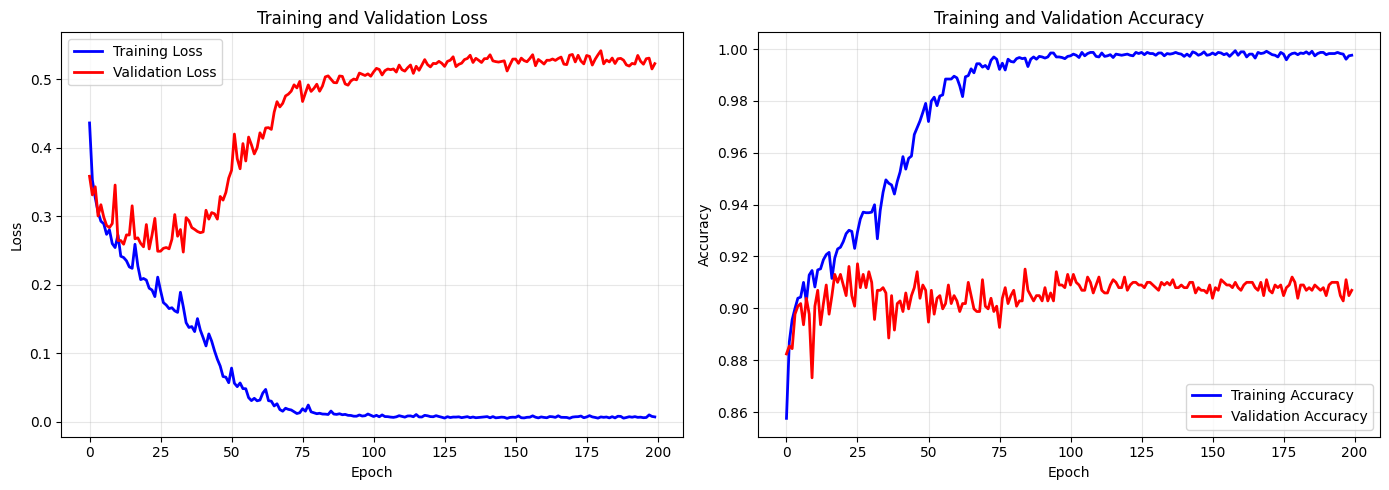

✓ Training curves saved
Final Training Loss: 0.0072
Final Validation Loss: 0.5229
Final Training Accuracy: 0.9976
Final Validation Accuracy: 0.9070


In [29]:
# ============================================================================
# PLOT TRAINING CURVES
# ============================================================================

# Check if training variables exist
if len(train_losses) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curves
    axes[0].plot(train_losses, label='Training Loss', color='blue', linewidth=2)
    axes[0].plot(val_losses, label='Validation Loss', color='red', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[1].plot(train_accs, label='Training Accuracy', color='blue', linewidth=2)
    axes[1].plot(val_accs, label='Validation Accuracy', color='red', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Create figures directory if it doesn't exist
    os.makedirs(os.path.join(PROCESSED_DIR, 'figures'), exist_ok=True)
    
    plt.savefig(os.path.join(PROCESSED_DIR, 'figures', 'training_curves.png'), dpi=300)
    plt.show()
    
    print(f"✓ Training curves saved")
    print(f"Final Training Loss: {train_losses[-1]:.4f}")
    print(f"Final Validation Loss: {val_losses[-1]:.4f}")
    print(f"Final Training Accuracy: {train_accs[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")
else:
    print("⚠️ Training hasn't been run yet. Please run Cell 10 (Training Loop) first.")

# 13: Confusion Matrix

Loaded class_names from metadata: {36: 'Alfalfa', 57: 'Rice', 69: 'Grapes', 74: 'Pistachios', 204: 'Almonds'}
Unique labels in test set: [0 1 2 3]
Filtered class names: {}
Class labels for matrix: []


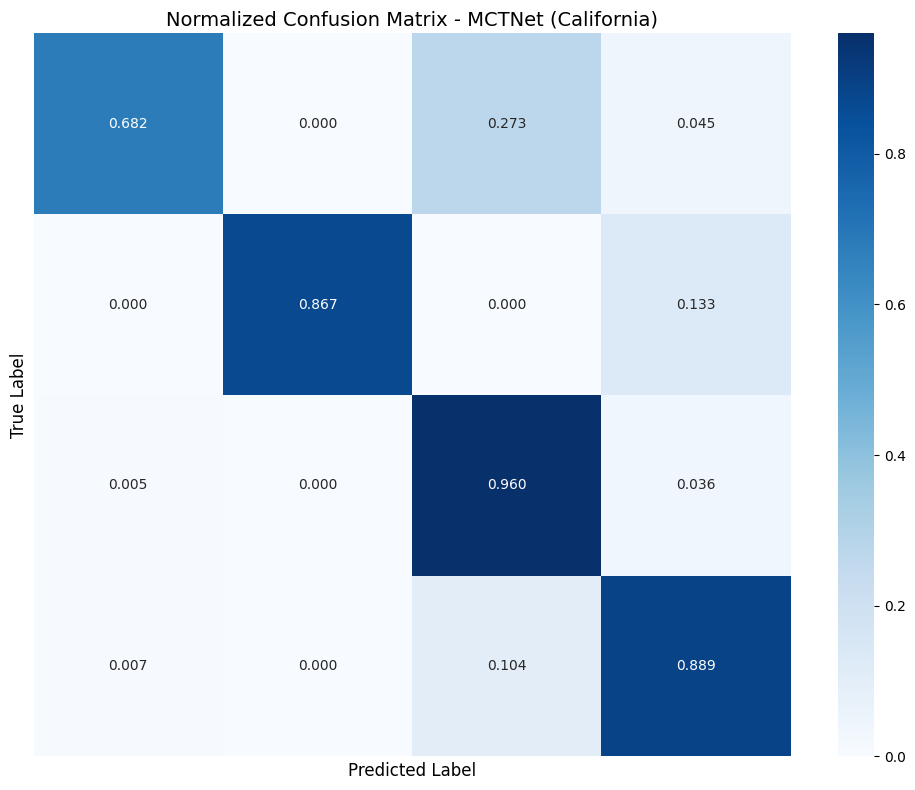


✓ Confusion matrix saved to: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed\figures\confusion_matrix_normalized.png


In [31]:
# ============================================================================
# CONFUSION MATRIX (FIXED)
# ============================================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get class names from metadata or define them
# Option 1: Load from metadata if available
try:
    class_names = metadata['crop_names']
    print(f"Loaded class_names from metadata: {class_names}")
except:
    # Option 2: Define manually if metadata not available
    class_names = {
        36: 'Alfalfa',
        57: 'Rice', 
        69: 'Grapes',
        204: 'Almonds'
    }
    print(f"Using manually defined class_names: {class_names}")

# Get the actual classes present in test set
unique_labels_in_test = np.unique(labels)
print(f"Unique labels in test set: {unique_labels_in_test}")

# Filter class_names to only those present in test set
filtered_class_names = {}
for label in unique_labels_in_test:
    # Find original crop code for this label
    original_code = idx_to_label[label] if 'idx_to_label' in dir() else label
    # Find the name
    for name, code in class_names.items():
        if code == original_code:
            filtered_class_names[name] = code
            break

print(f"Filtered class names: {filtered_class_names}")

# Create ordered lists for the confusion matrix
class_labels = list(filtered_class_names.keys())
print(f"Class labels for matrix: {class_labels}")

# 1. Calculate confusion matrix
cm = confusion_matrix(labels, preds)

# 2. Normalize by row (each row sums to 1.0)
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

# 3. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Normalized Confusion Matrix - MCTNet (California)', fontsize=14)
plt.tight_layout()

# Save
os.makedirs(os.path.join(PROCESSED_DIR, 'figures'), exist_ok=True)
plt.savefig(os.path.join(PROCESSED_DIR, 'figures', 'confusion_matrix_normalized.png'), dpi=300)
plt.show()

print(f"\n✓ Confusion matrix saved to: {os.path.join(PROCESSED_DIR, 'figures', 'confusion_matrix_normalized.png')}")

# 14: Save Model

In [ ]:
# ============================================================================
# SAVE MODEL (FIXED)
# ============================================================================

model_path = os.path.join(PROCESSED_DIR, 'mctnet_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'metrics': {
        'oa': oa,
        'kappa': kappa,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    },
    'class_names': class_names,
    'label_to_idx': label_to_idx,  # Save for later use
    'hyperparameters': {
        'd_model': 64,
        'nhead': 4,                    # ← Fixed: 4 not 5
        'n_stages': 3,
        'kernel_sizes': [3, 5, 7],     # ← Multi-scale
        'dropout': 0.1
    }
}, model_path)

print(f"\n✅ Model saved to: {model_path}")
print("\n" + "="*70)
print("PART 5 COMPLETE!")
print("="*70)


✅ Model saved to: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed\mctnet_model.pth

PART 5 COMPLETE!
